# Hide and Seek in the Signal Forest
Welcome to the hardware-in-the-loop verification playground. 

In this demonstration, we are going to look for two signals hidden within a noisy time-domain "forest":
* **Goliath:** A massive, full-scale signal (0 dB).
* **David:** A tiny, weak signal buried **80 dB** below Goliath.

Because David's amplitude is hovering right on the edge of our 16-bit fixed-point resolution, he is completely invisible in the time domain. Let's generate the signal, apply a Hann window, and see what the FPGA will be dealing with.

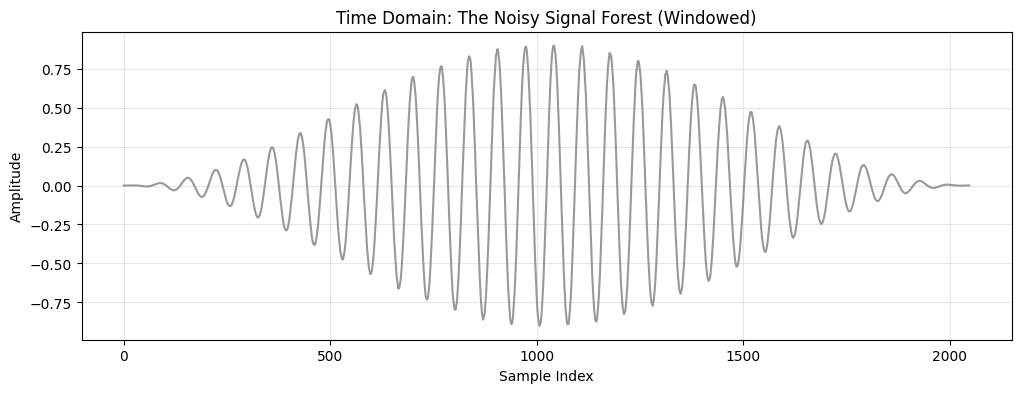

Goliath Amplitude: 0.9000
David Amplitude:   0.001778 (Buried in noise)


In [292]:
import numpy as np
import matplotlib.pyplot as plt
from fft_utils import run_sim, analyze_fft_performance

# 1. Setup Parameters
N = 2048
t = np.arange(N)

# 2. Generate Goliath (High amplitude, low frequency)
goliath_freq = 30
goliath_amp = 0.90
goliath = goliath_amp * np.sin(2 * np.pi * goliath_freq * t / N)

# 3. Generate David (Tiny amplitude, high frequency)
david_freq = 200
david_amp = 10**(-55/20) # -80 dB relative to Goliath
david = david_amp * np.sin(2 * np.pi * david_freq * t / N)

# 4. Generate the "Forest" (White noise)
noise_floor = 0.005 * np.random.randn(N) 

# Combine and apply windowing to prevent spectral leakage
raw_signal = goliath + david + noise_floor
window = np.hanning(N)
input_sig = np.zeros(N, dtype=complex)
input_sig = raw_signal * window

# Plot the Time Domain
plt.figure(figsize=(12, 4))
plt.plot(t, input_sig, color='gray', alpha=0.8)
plt.title("Time Domain: The Noisy Signal Forest (Windowed)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Goliath Amplitude: {goliath_amp:.4f}")
print(f"David Amplitude:   {david_amp:.6f} (Buried in noise)")

## Moving to the Frequency Domain
If we feed this data into our VHDL core, the hardware will perform the Radix-2 DIF FFT using internal **Q2.14** precision and Block Floating Point scaling. 

Let's run the simulation and plot the magnitude spectrum. Thanks to the "Processing Gain" of a 1024-point FFT, the hardware should push the noise floor down far enough to reveal David.

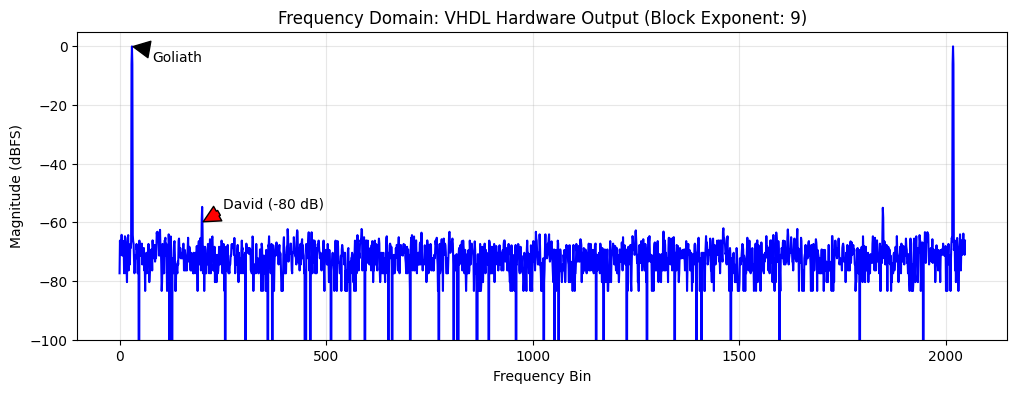

In [293]:
# --- Step 1: Forward FFT through VHDL ---
fft_hw, e1, cycles = run_sim(input_sig, invert=False)

# Calculate Magnitudes (in dB for visibility)
# Add a tiny offset to prevent log(0)
hw_mag = np.abs(fft_hw) + 1e-12 
hw_mag_db = 20 * np.log10(hw_mag / np.max(hw_mag))

# Plot the Frequency Domain
plt.figure(figsize=(12, 4))
plt.plot(hw_mag_db, 'b-', linewidth=1.5)
plt.title(f"Frequency Domain: VHDL Hardware Output (Block Exponent: {e1})")
plt.xlabel("Frequency Bin")
plt.ylabel("Magnitude (dBFS)")
plt.ylim([-100, 5])
plt.grid(True, alpha=0.3)

# Annotate the peaks
plt.annotate('Goliath', xy=(goliath_freq, 0), xytext=(goliath_freq+50, -5),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate('David (-80 dB)', xy=(david_freq, -60), xytext=(david_freq+50, -55),
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.show()

## Digital Filtering and Reconstruction
Now that we have found them, let's extract them. 

Because the FFT is perfectly reversible, we can act as a digital filter. We will create two new arrays: one where we zero-out everything *except* Goliath's frequency bins, and one where we keep *only* David's bins. 

Then, we pass both arrays back through the hardware core using the Inverse FFT (`invert=True`) to reconstruct them in the time domain.

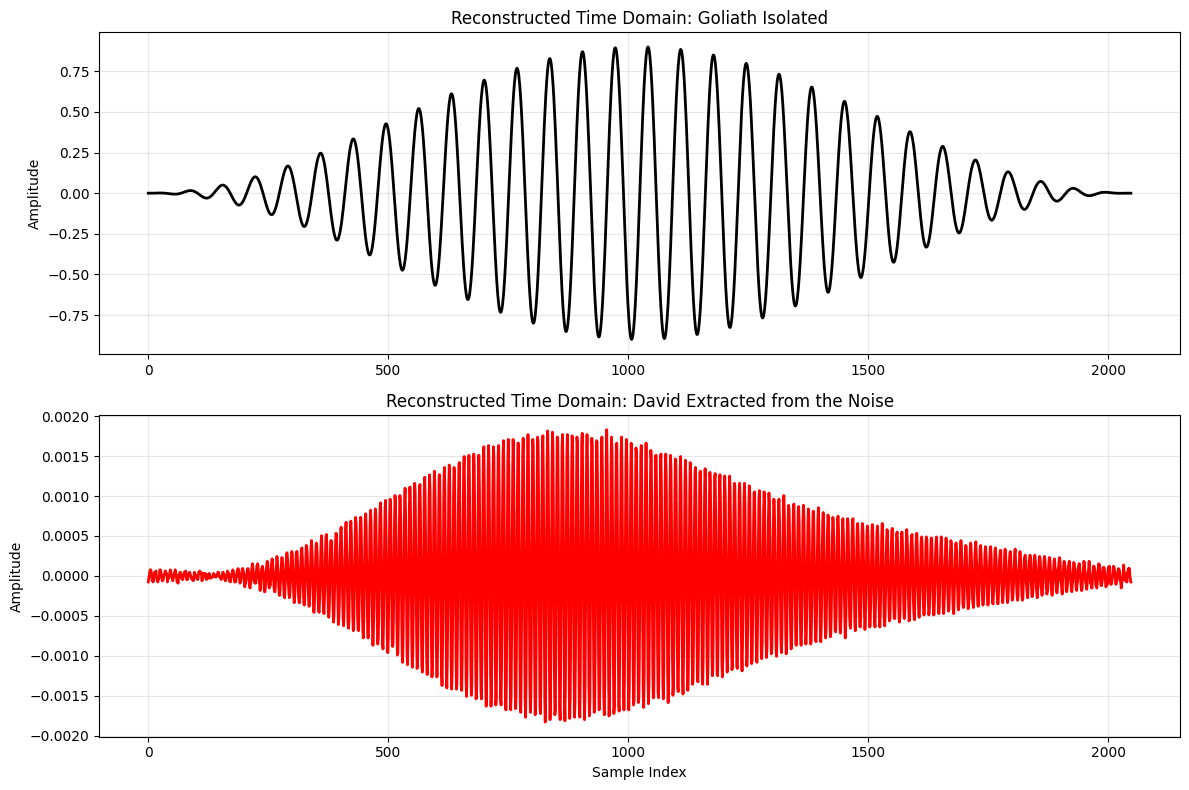

In [294]:
# Create empty arrays for our isolated signals
fft_goliath = np.zeros_like(fft_hw)
fft_david = np.zeros_like(fft_hw)

# Isolate Goliath (Bin 30 and its Nyquist mirror)
fft_goliath[goliath_freq-2 : goliath_freq+3] = fft_hw[goliath_freq-2 : goliath_freq+3]
fft_goliath[N-goliath_freq-2 : N-goliath_freq+3] = fft_hw[N-goliath_freq-2 : N-goliath_freq+3]

# Isolate David (Bin 200 and its Nyquist mirror)
fft_david[david_freq-2 : david_freq+3] = fft_hw[david_freq-2 : david_freq+3]
fft_david[N-david_freq-2 : N-david_freq+3] = fft_hw[N-david_freq-2 : N-david_freq+3]

# --- Step 2: Inverse FFT through VHDL ---
recon_goliath, e2_g, _ = run_sim(fft_goliath, invert=True)
recon_david, e2_d, _ = run_sim(fft_david, invert=True)

# Apply scaling equation to restore actual amplitudes
final_goliath = (recon_goliath.real * (2.0**(e1 + e2_g))) / N
final_david = (recon_david.real * (2.0**(e1 + e2_d))) / N

# Plot the Reconstructed Time Domain Signals
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Goliath Plot
ax1.plot(t, final_goliath, 'k-', linewidth=2)
ax1.set_title("Reconstructed Time Domain: Goliath Isolated")
ax1.set_ylabel("Amplitude")
ax1.grid(True, alpha=0.3)

# David Plot (Notice the y-axis scale!)
ax2.plot(t, final_david, 'r-', linewidth=2)
ax2.set_title("Reconstructed Time Domain: David Extracted from the Noise")
ax2.set_xlabel("Sample Index")
ax2.set_ylabel("Amplitude")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()